**Nessa versão ajustada do codigo original publicada no artigo:**
- são obtidos os mesmos resultados da versão original
- são realizadas mudanças na estrutura do notebook para facilitar a navegabilidade pelo codigo
- serão incluidos os codigos para reprodução de graficos e tabelas contidas no texto da dissertação



**ETAPAS**

1. Reproduzir os resultados de todas as tabelas e graficos do artigo 


# 0. Imports and global configuration


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import cross_val_predict, KFold, train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Data loading and description 

## Read data

In [2]:
# Load Dataset (replace 'file_path' with your file location in Colab)
file_path = './content/dados_jamovi.xlsx'  # Upload your dataset to Colab
data = pd.read_excel(file_path)


## Data Description

In [3]:
data.head()

,Dmax (mean) [µm],Dmed (mean) [µm],Dmin (mean) [µm],Area (mean) [µm²],Velocity (mean) [µm/s],Distance (sum) [µm],Rel.Time (num) [s],Area (polygon) (mean) [µm²],Area/Box (mean) [µm²],Axis (major) (mean) [µm],...,Perim. (convex) (mean) [µm],Perim. (ellipse) (mean) [µm],Perim. (ratio) (mean) [µm],Perimeter2 (mean) [µm],Perimeter3 (mean) [µm],Radius (max) (mean) [µm],Radius (min) (mean) [µm],Roundness (mean),Size (length) (mean) [µm],Size (width) (mean) [µm]
0,2278.275745,1551.198298,711.606809,1.612164e+06,1399.779783,6438.99,47,1466525.53,0.46,2284.51,...,5746.35,5338.09,0.82,7615.24,7006.98,1329.19,267.71,2.67,2360.02,1219.27
1,3442.800833,2611.194583,1959.983750,5.709536e+06,2415.071739,5554.67,24,5488243.60,0.73,3343.78,...,9110.69,8811.35,0.90,10708.58,10125.68,1770.54,859.83,1.49,3405.16,2470.43
2,2372.206296,1943.840370,1434.028889,3.149271e+06,2265.156923,5889.41,27,2978574.57,0.61,2279.25,...,7027.62,6492.88,0.81,9172.29,8647.90,1434.45,511.19,2.01,2495.45,2040.84
3,1921.425405,1496.906486,1080.961892,1.835665e+06,1804.333056,6495.60,37,1711958.32,0.63,1838.61,...,5162.67,4959.59,0.84,6476.37,6131.23,1031.68,466.54,1.75,1889.67,1450.77
4,1987.391429,1533.741429,934.360000,1.807783e+06,1861.068333,1116.64,7,1682195.05,0.59,2114.39,...,5396.27,5191.92,0.90,6369.07,5980.95,1079.78,418.74,1.69,2009.11,1196.00


In [4]:
data.info() # acrescentar a descricao das colunas e definir a variavel target

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Dmax (mean) [µm]               916 non-null    float64
 1   Dmed (mean) [µm]               916 non-null    float64
 2   Dmin (mean) [µm]               883 non-null    float64
 3   Area (mean) [µm²]              916 non-null    float64
 4   Velocity (mean) [µm/s]         916 non-null    float64
 5   Distance (sum) [µm]            916 non-null    float64
 6   Rel.Time (num) [s]             916 non-null    int64  
 7   Area (polygon) (mean) [µm²]    916 non-null    float64
 8   Area/Box (mean) [µm²]          916 non-null    float64
 9   Axis (major) (mean) [µm]       916 non-null    float64
 10  Axis (minor) (mean) [µm]       916 non-null    float64
 11  Box Height (mean) [µm]         916 non-null    float64
 12  Box Width (mean) [µm]          916 non-null    flo

# 2. Declare predictor and target variable

In [5]:
target_column = 'Velocity (mean) [µm/s]'
features_columns = [col for col in data.columns if col != target_column]

In [6]:
X = data[features_columns]
y = data[target_column]

# 3. Modeling Experiments

## A - Traditional Gradient Boosting Regressor 


### Feature engineering



In [7]:
# Copy data
X_run1 = X.copy()
y_run1 = y.copy()

### Observacao 

Aqui temos um leakage, porem quase irrelevante, já que os poucos nulos que ha no dataset estao numa variavel pouco importante para o modelo, no caso o "D"

In [8]:
# Impute Missing Values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_run1)

### Traning model

In [9]:

# Define the Gradient Boosting Regressor
traditional_gbr_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)


### 5-Fold Cross-Validation

In [10]:

# Perform 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_pred_gbr = cross_val_predict(traditional_gbr_model, X_imputed, y_run1, cv=kf)


In [11]:

# Calculate Metrics for Cross-Validation
cv_mae = mean_absolute_error(y_run1, cv_pred_gbr)
cv_rmse = np.sqrt(mean_squared_error(y_run1, cv_pred_gbr))
cv_r2 = r2_score(y_run1, cv_pred_gbr)


In [12]:

# Results
print("5-Fold Cross-Validation Metrics:")
print(f"MAE:  {cv_mae}")
print(f"RMSE: {cv_rmse}")
print(f"R^2:  {cv_r2}")


5-Fold Cross-Validation Metrics:
MAE:  234.31456825890695
RMSE: 397.48962627853695
R^2:  0.8868770918785022


In [13]:
results = {
    "model_name": "GBR Tradicional",
    "MAE": cv_mae, 
    "RMSE": cv_rmse, 
    "R2": cv_r2
}

gbr_results = pd.DataFrame(results, index=[0])
gbr_results


,model_name,MAE,RMSE,R2
0,GBR Tradicional,234.314568,397.489626,0.886877


### Save results for evaluation analysis

In [14]:
df_eval_A = pd.DataFrame({
    "y_true": y_run1,
    "y_pred": cv_pred_gbr,
    "experiment": "GBR Tradicional"
})


## Experiment B - Physics-based feature engineering Gradient Boosting Regressor (PFE - GBR)


- **Reynolds number (Re):** captures flow regime effects
- **Drag coefficient (Cd):** accounts for non-linear drag behavior
- **Drag force (Fd):** expresses momentum exchange

A characteristic velocity is used in the computation of these quantities and is obtained from experimental measurements.

### Observacao 

Aui temos o mesmo problema de leakage do modelo anterior, somado ao fato de que a velocidade caracteristica, inserida em Reynolds, é a variavel resposta do sistema

### Feature Engineering

In [15]:
# Copy data
X_run2 = X.copy()
y_run2 = y.copy()
data_run2 = data.copy()

In [ ]:
# Physical Constants for Feature Engineering
g = 9.81  # Gravitational acceleration (m/s²)
rho_p = 2600  # Particle density (kg/m³)
rho_f = 1000  # Fluid density (kg/m³)
mu = 0.001  # Dynamic viscosity of water (Pa·s)



# Physics-Informed Feature Engineering
data_run2['Radius (m)'] = data_run2['Radius (max) (mean) [µm]'] * 1e-6  # Convert µm to meters
data_run2['Area (m²)'] = data_run2['Area (mean) [µm²]'] * 1e-12  # Convert µm² to m²

# Correct Reynolds Number
data_run2['Re'] = (rho_f * data_run2[target_column] * 1e-6 * data_run2['Radius (m)']) / mu  # Re = (rho * v * r) / mu

# Adjust Drag Coefficient for Low Reynolds Number (Stokes regime)
data_run2['Cd'] = 24 / data_run2['Re']  # Cd = 24/Re for laminar regime

# Correct Drag Force using the adjusted Cd
data_run2['Drag Force'] = 0.5 * rho_f * data_run2['Cd'] * data_run2['Area (m²)'] * ((data_run2[target_column] * 1e-6) ** 2)  # Fd = 0.5 * rho * Cd * A * v^2

# Stokes' Settling Velocity (para referência)
data_run2['Stokes Velocity'] = (2 / 9) * ((rho_p - rho_f) * g * (data_run2['Radius (m)'] ** 2) / mu)

# Include Physics-Informed Features
physics_features = ['Radius (m)', 'Re', 'Cd', 'Drag Force']
X_pfe = pd.concat([X_run2, data_run2[physics_features]], axis=1)


In [16]:
# Versao 2 da Feature Engineering
# Principal diferença dessa versao da feature engineering é a utilizacao do d (em lugar do 'Radius (max) (mean) [µm]') para o calculo de Re

rho_f = 1000.0
mu = 0.001
g = 9.81  # Gravitational acceleration (m/s²)
rho_p = 2600  # Particle density (kg/m³)

A = data_run2["Area (mean) [µm²]"] * 1e-12
r = data_run2["Radius (max) (mean) [µm]"] * 1e-6
v = data_run2[target_column] * 1e-6

d = 2.0 * np.sqrt(A / np.pi)
Re = (rho_f * v * d) / mu # no codigo original em vez de "d" usamos simplesmente o raio 
Re = Re.replace([np.inf, -np.inf], np.nan)
Re = Re.where(Re > 0, np.nan)

Re = (
    Re
    .where(Re > 0) # remove valores não físicos
    .replace([np.inf, -np.inf], np.nan) # remove infinitos
)
# “Non-physical Reynolds number values (Re ≤ 0) and infinite values arising from numerical instabilities were discarded and treated as missing data prior to model training.”
# Re = 0 representa velocidade nula o que nao importa no processo
# Re < 0 nao faz sentido, dado que velocidade e as outras variaveis nunca serao menor que 0

Cd = 24.0 / Re
Fd = 0.5 * rho_f * Cd * A * (v ** 2)
r2 = r ** 2
Stokes = (2 / 9) * ((rho_p - rho_f) * g * r2 / mu)

data_run2["PFE_Re"] = Re
data_run2["PFE_Cd"] = Cd
data_run2["PFE_Fd"] = Fd
data_run2["PFE_r2"] = r2


physics_features = ['PFE_r2', 'PFE_Re', 'PFE_Cd', 'PFE_Fd']
X_pfe = pd.concat([X_run2, data_run2[physics_features]], axis=1)


In [17]:

# Impute Missing Values
imputer = SimpleImputer(strategy='mean')
X_pfe_imputed = imputer.fit_transform(X_pfe)


### Training model

In [18]:

# Define the Gradient Boosting Regressor
pfe_gbr_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)


### 5-Fold Cross-Validation

obs: como é feito imputer por media, esta havendo leakage nas predicoes por cross validation

In [ ]:
## Essa run com feature engineering versao 2 teve resultado ligeiramente superior à original do paper. Por que? 

# # Perform 5-Fold Cross-Validation
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# cv_pred_pfe = cross_val_predict(pfe_gbr_model, X_pfe_imputed, y_run2, cv=kf)

# # Calculate Metrics for Cross-Validation
# pfe_cv_mae = mean_absolute_error(y_run2, cv_pred_pfe)
# pfe_cv_rmse = np.sqrt(mean_squared_error(y_run2, cv_pred_pfe))
# pfe_cv_r2 = r2_score(y_run2, cv_pred_pfe)

# # Results
# print("5-Fold Cross-Validation Metrics:")
# print(f"MAE: {pfe_cv_mae}")
# print(f"RMSE: {pfe_cv_rmse}")
# print(f"R^2: {pfe_cv_r2}")


5-Fold Cross-Validation Metrics:
MAE: 121.05019989194962
RMSE: 224.5689079242671
R^2: 0.9638924336827517


In [21]:

# Perform 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_pred_pfe = cross_val_predict(pfe_gbr_model, X_pfe_imputed, y_run2, cv=kf)

# Calculate Metrics for Cross-Validation
pfe_cv_mae = mean_absolute_error(y_run2, cv_pred_pfe)
pfe_cv_rmse = np.sqrt(mean_squared_error(y_run2, cv_pred_pfe))
pfe_cv_r2 = r2_score(y_run2, cv_pred_pfe)

# Results
print("5-Fold Cross-Validation Metrics:")
print(f"MAE: {pfe_cv_mae}")
print(f"RMSE: {pfe_cv_rmse}")
print(f"R^2: {pfe_cv_r2}")


5-Fold Cross-Validation Metrics:
MAE: 136.0491303563949
RMSE: 261.5529512797582
R^2: 0.9510200640158917


In [22]:
results = {
    "model_name": "Physics-based feature engineering GBR",
    "MAE": pfe_cv_mae, 
    "RMSE": pfe_cv_rmse, 
    "R2": pfe_cv_r2
}

pfe_gbr_results = pd.DataFrame(results, index=[0])
pfe_gbr_results

,model_name,MAE,RMSE,R2
0,Physics-based feature engineering GBR,136.04913,261.552951,0.95102


### Save results for evaluation analysis

In [23]:
df_eval_B = pd.DataFrame({
    "y_true": y_run2,
    "y_pred": cv_pred_pfe,
    "experiment": "PFE - GBR"
})

## Comparing model's performance

In [24]:
all_results = pd.concat([gbr_results, pfe_gbr_results])

In [25]:
all_results

,model_name,MAE,RMSE,R2
0,GBR Tradicional,234.314568,397.489626,0.886877
0,Physics-based feature engineering GBR,136.049130,261.552951,0.951020


# 4. Holdout Evaluation and Error Interpretation

In [26]:
df_eval_B

,y_true,y_pred,experiment
0,1399.779783,1488.656789,PFE - GBR
1,2415.071739,2273.504971,PFE - GBR
2,2265.156923,2344.774550,PFE - GBR
3,1804.333056,1690.001367,PFE - GBR
4,1861.068333,1636.239657,PFE - GBR
...,...,...,...
911,2872.106122,2920.474827,PFE - GBR
912,1696.029730,1800.435853,PFE - GBR
913,1725.002941,1896.919326,PFE - GBR
914,1702.832653,1769.868357,PFE - GBR


In [27]:
df_evaluation_analysis = pd.concat(
    [df_eval_A, df_eval_B],
    axis=0
)

In [28]:
df_evaluation_analysis

,y_true,y_pred,experiment
0,1399.779783,1544.494015,GBR Tradicional
1,2415.071739,2839.999946,GBR Tradicional
2,2265.156923,2196.957496,GBR Tradicional
3,1804.333056,1667.759913,GBR Tradicional
4,1861.068333,1577.369906,GBR Tradicional
...,...,...,...
911,2872.106122,2920.474827,PFE - GBR
912,1696.029730,1800.435853,PFE - GBR
913,1725.002941,1896.919326,PFE - GBR
914,1702.832653,1769.868357,PFE - GBR


In [29]:
# criar resíduos
df_evaluation_analysis["residual"] = df_evaluation_analysis["y_true"] - df_evaluation_analysis["y_pred"]

# separar experimentos
df_evaluation_analysis_trad = df_evaluation_analysis[df_evaluation_analysis["experiment"] == "GBR Tradicional"]
df_evaluation_analysis_pfe  = df_evaluation_analysis[df_evaluation_analysis["experiment"] == "PFE - GBR"]

In [30]:
# Aqui testarei o holdout pra ver se o resultado se aproxima do obtido pelo professor
y_run2
X_pfe_imputed

array([[2.27827574e+03, 1.55119830e+03, 7.11606809e+02, ...,
        1.86057329e+00, 1.28992500e+01, 2.03733833e-08],
       [3.44280083e+03, 2.61119458e+03, 1.95998375e+03, ...,
        4.27598112e+00, 5.61274696e+00, 9.34558270e-08],
       [2.37220630e+03, 1.94384037e+03, 1.43402889e+03, ...,
        3.24925435e+00, 7.38631004e+00, 5.96766103e-08],
       ...,
       [2.79967739e+03, 1.89434754e+03, 8.13373529e+02, ...,
        2.79269351e+00, 8.59385389e+00, 3.05732465e-08],
       [2.31261000e+03, 1.68249020e+03, 7.94600408e+02, ...,
        2.10664239e+00, 1.13925364e+01, 3.65602214e-08],
       [1.61395690e+03, 1.13807024e+03, 6.45874878e+02, ...,
        1.12681957e+00, 2.12988847e+01, 1.68941123e-08]], shape=(916, 41))

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pfe_imputed, y_run2, test_size = 0.2, random_state=42
)

model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

y_predicted = model.predict(X_test)

In [32]:
y_residual = y_test - y_predicted

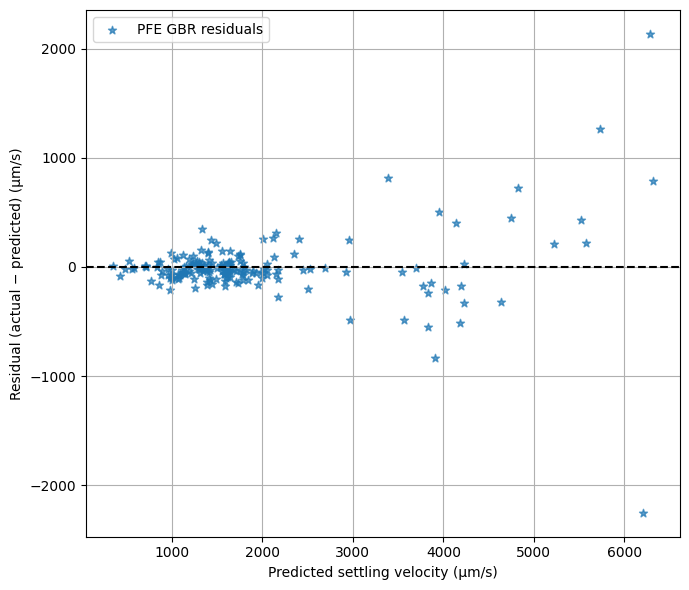

In [33]:
plt.figure(figsize=(7, 6))

# resíduos PFE
plt.scatter(
    y_predicted,
    y_residual,
    marker="*",
    alpha=0.7,
    label="PFE GBR residuals"
)

# linha zero
plt.axhline(
    0,
    linestyle="--",
    color="black"
)

plt.xlabel("Predicted settling velocity (µm/s)")
plt.ylabel("Residual (actual − predicted) (µm/s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Real vs Predicted Velocity


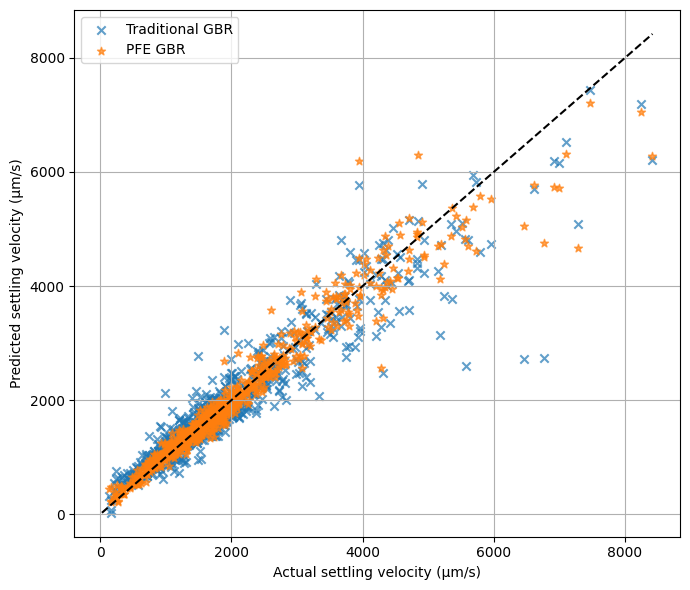

In [34]:
plt.figure(figsize=(7, 6))

# scatter tradicional
plt.scatter(
    df_evaluation_analysis_trad["y_true"],
    df_evaluation_analysis_trad["y_pred"],
    marker="x",
    alpha=0.7,
    label="Traditional GBR"
)

# scatter PFE
plt.scatter(
    df_evaluation_analysis_pfe["y_true"],
    df_evaluation_analysis_pfe["y_pred"],
    marker="*",
    alpha=0.7,
    label="PFE GBR"
)

# linha identidade
min_val = min(df_evaluation_analysis["y_true"].min(), df_evaluation_analysis["y_pred"].min())
max_val = max(df_evaluation_analysis["y_true"].max(), df_evaluation_analysis["y_pred"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="black"
)

plt.xlabel("Actual settling velocity (µm/s)")
plt.ylabel("Predicted settling velocity (µm/s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Error Analysis

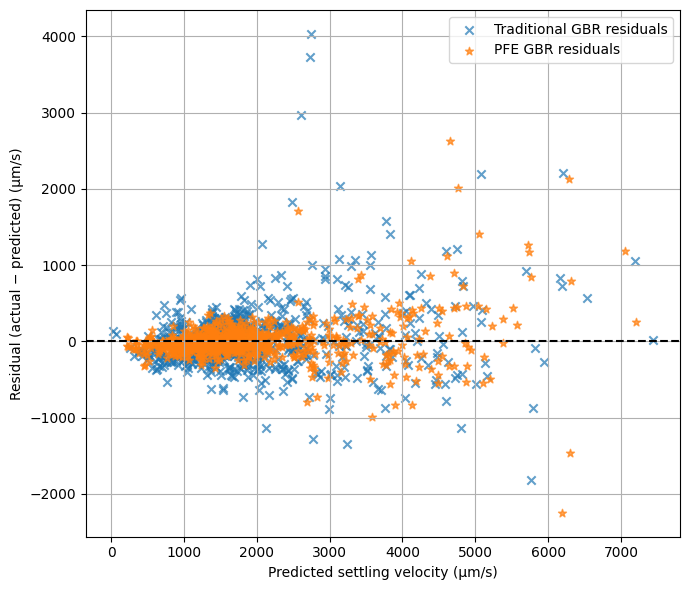

In [35]:
plt.figure(figsize=(7, 6))

# resíduos tradicional
plt.scatter(
    df_evaluation_analysis_trad["y_pred"],
    df_evaluation_analysis_trad["residual"],
    marker="x",
    alpha=0.7,
    label="Traditional GBR residuals"
)

# resíduos PFE
plt.scatter(
    df_evaluation_analysis_pfe["y_pred"],
    df_evaluation_analysis_pfe["residual"],
    marker="*",
    alpha=0.7,
    label="PFE GBR residuals"
)

# linha zero
plt.axhline(
    0,
    linestyle="--",
    color="black"
)

plt.xlabel("Predicted settling velocity (µm/s)")
plt.ylabel("Residual (actual − predicted) (µm/s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# 5. Model Interpretability - SHAP Values

In [36]:
explainer = shap.Explainer(traditional_gbr_model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

# 6. Robustness Analysis - Noise Injection

def inject_noise(X, noise_level):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise


In [ ]:
noise_levels = [0.0, 0.01, 0.05, 0.1]
results_noise = []

for nl in noise_levels:
    X_noisy = inject_noise(X_physics, nl)
    res = evaluate_cv(gbr, X_noisy, y)
    res["noise_level"] = nl
    results_noise.append(res)

df_noise = pd.DataFrame(results_noise)
df_noise

## Performance Degradation Under Noise

plt.plot(df_noise["noise_level"], df_noise["RMSE_mean"], marker="o")
plt.xlabel("Noise Level")
plt.ylabel("RMSE")
plt.title("RMSE vs Noise Level")
plt.show()


# 7. Error Analysis by Morphological Class

In [ ]:
classes = df.loc[X_test.index, "morphological_class"]

error_by_class = (
    pd.DataFrame({
        "class": classes,
        "abs_error": np.abs(residuals)
    })
    .groupby("class")
    .mean()
)

error_by_class